In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import io
from PIL import Image
import numpy as np
import torch
import pickle


def gen_one_traj_img(x_min, x_max, y_min, y_max, u_max, radius, dt, v, dpi, start_state):
    x_max -= 0.1
    y_max -= 0.1
    x_min += 0.1
    y_min += 0.1
    center = (0.0, 0.0)
    states = torch.zeros(3)
    states[0] = start_state[0]
    states[1] = start_state[1]
    states[2] = start_state[2]

    state_obs, img_obs, state_gt, dones, acs = ([] for _ in range(5))
    # t_max = 3
    t_max = 1

    for t in range(t_max):
        if torch.abs(states[0]) > 1.0 or torch.abs(states[1]) > 1.0:
            dones[-1] = 1
            break

        # continuous action-space
        ac = (2 * u_max) * (torch.rand(1) - 0.5)
        
        states_next = torch.rand(3)
        states_next[0] = states[0] + v*dt*torch.cos(states[2])
        states_next[1] = states[1] + v*dt*torch.sin(states[2])
        states_next[2] = states[2] + dt*ac

        state_obs.append(states[2].numpy()) # get to observe theta
        state_gt.append(states.numpy()) # gt state
        dones.append(1)
        acs.append(ac)

        fig,ax = plt.subplots()
        plt.xlim([-1.1, 1.1])
        plt.ylim([-1.1, 1.1])
        plt.axis('off')
        fig.set_size_inches( 1, 1 )
        # Create the circle patch
        circle = patches.Circle(center, radius, edgecolor=(1,0,0), facecolor='none')
        # Add the circle patch to the axis
        ax.add_patch(circle)
        plt.quiver(states[0], states[1], dt*v*torch.cos(states[2]), dt*v*torch.sin(states[2]),
             angles='xy', scale_units='xy', minlength=0,width=0.1, scale=0.18,color=(0,0,1), zorder=3)
        plt.scatter(states[0], states[1],s=20, color=(0,0,1), zorder=3)
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=dpi)
        buf.seek(0)

        # Load the buffer content as an RGB image
        img = Image.open(buf).convert('RGB')
        img_array = np.array(img)
        img_obs.append(img_array)
        plt.close()
        states = states_next
    
    return state_obs, acs, state_gt, img_obs, dones

def generate_trajs(x_min, x_max, y_min, y_max, u_max, r, dt, v, num_pts, dpi):
    demos = []
    k = 0
    tot = num_pts*num_pts
    for i in range(num_pts):
        for j in range(num_pts):
            # start_state = [x_min+0.1 + (x_max-x_min-0.2)*i/(num_pts-1),
            #                y_min+0.1 + (y_max-y_min-0.2)*j/(num_pts-1), 0]
            start_state = [x_min+0.1 + (x_max-x_min-0.2)*i/(num_pts-1),
                           y_min+0.1 + (y_max-y_min-0.2)*j/(num_pts-1), np.pi/2]
            print(f'demo: {k} / {tot}', end='\r')
            k += 1
            state_obs, acs, state_gt, img_obs, dones = gen_one_traj_img(x_min, x_max, y_min, y_max, u_max, r, dt, v, dpi, start_state)
            demo = {}
            demo['obs'] = {'image': img_obs, 'state': state_obs, 'priv_state': state_gt}
            demo['actions'] = acs
            demo['dones'] = dones
            demos.append(demo)
    
    with open('wm_demos_cont_act'+str(dpi)+'grid_pi-half_single.pkl', 'wb') as f:
        pickle.dump(demos, f)

num_pts = 3
x_min = -1.1
x_max = 1.1
y_min = -1.1
y_max = 1.1

u_max = 1.25
dt = 0.05
v = 1.
r = 0.5

dpi = 128
demos = generate_trajs(x_min, x_max, y_min, y_max, u_max, r, dt, v, num_pts, dpi)


In [35]:
import pickle

# pkl_file = "wm_demos_cont_act128grid.pkl"
pkl_file = "wm_demos_cont_act128grid_pi-half.pkl"
# pkl_file = "wm_demos_cont_act128grid_pi-half_single.pkl"
with open(pkl_file, 'rb') as f:
    demo_data = pickle.load(f)

len(demo_data)

2500

In [22]:
demo1_img = demo_data[0]['obs']['image'][0]
demo1_state = demo_data[0]['obs']['state'][0]
print(demo1_img.shape)
print(demo1_state)

(128, 128, 3)
1.5707964


In [ ]:
import argparse
import sys
import gymnasium #as gym
import gym
import numpy as np
import torch

parent_dir = "/home/clown2/Desktop/Work/Courses/EAIS/"
sys.path.append(parent_dir)
dreamer_dir = "/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch"
sys.path.append(dreamer_dir)
print(sys.path)

import models
import tools
import ruamel.yaml as yaml
from PyHJ.exploration import GaussianNoise
from PyHJ.utils.net.common import Net
from PyHJ.utils.net.continuous import Actor, Critic

from termcolor import cprint
from datetime import datetime
import pathlib
import collections

# note: need to include the dreamerv3 repo for this
from dreamer import make_dataset

# Remove Jupyter's arguments before creating the parser
if '--f' in sys.argv:
    # Find the index of the Jupyter argument
    f_idx = sys.argv.index('--f')
    # Remove the argument and its value
    sys.argv.pop(f_idx)
    if f_idx < len(sys.argv):
        sys.argv.pop(f_idx)
        
# Alternatively, a more comprehensive approach:
if 'ipykernel_launcher.py' in sys.argv[0]:
    # Remove all arguments that Jupyter might have added
    sys.argv = [sys.argv[0]]

def recursive_update(base, update):
    for key, value in update.items():
        if isinstance(value, dict) and key in base:
            recursive_update(base[key], value)
        else:
            base[key] = value

def get_args():
    parser = argparse.ArgumentParser()
    
    parser.add_argument("--configs", nargs="+")
    parser.add_argument("--expt_name", type=str, default=None)
    parser.add_argument("--resume_run", type=bool, default=False)
    # environment parameters
    config, remaining = parser.parse_known_args()


    if not config.resume_run:
        curr_time = datetime.now().strftime("%m%d/%H%M%S")
        config.expt_name = (
            f"{curr_time}_{config.expt_name}" if config.expt_name else curr_time
        )
    else:
        assert config.expt_name, "Need to provide experiment name to resume run."

    yml = yaml.YAML(typ="safe", pure=True)
    configs = yml.load((pathlib.Path(sys.argv[0]).parent.parent.parent.parent.parent / "/home/clown2/Desktop/Work/Courses/EAIS/PytorchReachability/HJconfig.yaml").read_text())
    name_list = ["defaults", *config.configs] if config.configs else ["defaults"]
    defaults = {}

    for name in name_list:
        recursive_update(defaults, configs[name])
    parser = argparse.ArgumentParser()
    for key, value in sorted(defaults.items(), key=lambda x: x[0]):
        arg_type = tools.args_type(value)
        parser.add_argument(f"--{key}", type=arg_type, default=arg_type(value))
    final_config = parser.parse_args(remaining)

    final_config.logdir = f"{final_config.logdir+'/lcrl'}/{config.expt_name}"

    print("---------------------")
    cprint(f"Experiment name: {config.expt_name}", "red", attrs=["bold"])
    cprint(f"Task: {final_config.task_lcrl}", "cyan", attrs=["bold"])
    cprint(f"Logging to: {final_config.logdir+'/lcrl'}", "cyan", attrs=["bold"])
    print("---------------------")
    return final_config


args=get_args()
config = args

# set up the environment spaces
image_size = config.size[0] #128
img_obs_space = gym.spaces.Box(low=0, high=255, shape=(image_size, image_size, 3), dtype=np.uint8)
obs_space = gym.spaces.Box(low=0, high=1, shape=(2,), dtype=np.float32)
high = np.array([1.1, 1.1, 2*np.pi,])
low = np.array([-1.1, -1.1, 0.,])
gt_observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)
bool_space = gym.spaces.Box(low=False, high=True, shape=(), dtype=bool)
observation_space = gym.spaces.Dict({'obs_state': obs_space,
                                     'image': img_obs_space,
                                     'state': gt_observation_space,})
u_max = 1.25
action_space = gym.spaces.Box(low=-u_max, high=u_max, shape=(1,), dtype=np.float32)
config.num_actions = action_space.n if hasattr(action_space, "n") else action_space.shape[0]

# load WM
wm = models.WorldModel(observation_space, action_space, 0, config)
ckpt_path = '/home/clown2/Desktop/Work/Courses/EAIS/logs/dreamer_dubins/best_pretrain_joint_0_12.pt'
checkpoint = torch.load(ckpt_path)
state_dict = {k[14:]:v for k,v in checkpoint['agent_state_dict'].items() if '_wm' in k}
wm.load_state_dict(state_dict)

directory = '/home/clown2/Desktop/Work/Courses/EAIS/wm_demos_cont_act128.pkl'
train_eps = tools.load_episodes(directory, limit=config.dataset_size)
expert_eps = collections.OrderedDict()

config.batch_size = 1
config.batch_length = 5
# only need this
train_dataset = make_dataset(train_eps, config)
tools.fill_expert_dataset_dubins(config, expert_eps)
expert_dataset = make_dataset(expert_eps, config)

# NOTE: should only need 1 dataset: the offline dataset u collected from the script.
datasets = [train_dataset, expert_dataset]


env = gymnasium.make(args.task_lcrl, params = [wm, datasets, config])
assert hasattr(env, 'action_space')
args.state_shape = env.observation_space.shape or env.observation_space.n
args.action_shape = env.action_space.shape or env.action_space.n
args.max_action = env.action_space.high[0]

args.action1_shape = env.action_space.shape or env.action_space.n
args.max_action1 = env.action_space.high[0]

# seed
np.random.seed(args.seed)
torch.manual_seed(args.seed)

activation_map = {
    'ReLU': torch.nn.ReLU,
    'Tanh': torch.nn.Tanh,
    'Sigmoid': torch.nn.Sigmoid,
    'SiLU': torch.nn.SiLU
}

actor_activation = activation_map.get(args.actor_activation)
critic_activation = activation_map.get(args.critic_activation)

assert args.critic_net is not None, "Please provide critic_net!"
    
critic_net = Net(
    args.state_shape,
    args.action_shape,
    hidden_sizes=args.critic_net,
    activation=critic_activation,
    concat=True,
    device=args.device
    )

critic = Critic(critic_net, device=args.device).to(args.device)
critic_optim = torch.optim.Adam(critic.parameters(), lr=args.critic_lr)

from PyHJ.policy import avoid_DDPGPolicy_annealing as DDPGPolicy

print("DDPG under the Avoid annealed Bellman equation with no Disturbance has been loaded!")

actor1_net = Net(args.state_shape, hidden_sizes=args.control_net, activation=actor_activation, device=args.device)
actor1 = Actor(actor1_net, args.action1_shape, max_action=args.max_action1, device=args.device).to(args.device)
actor1_optim = torch.optim.Adam(actor1.parameters(), lr=args.actor_lr)

policy = DDPGPolicy(
    critic,
    critic_optim,
    tau=args.tau,
    gamma=args.gamma_lcrl,
    exploration_noise=GaussianNoise(sigma=args.exploration_noise),
    reward_normalization=args.rew_norm,
    estimation_step=args.n_step,
    action_space=env.action_space,
    actor1=actor1,
    actor1_optim=actor1_optim,
    actor_gradient_steps=args.actor_gradient_steps,
    )

# load policy
policy_path = "dreamer_l2_lessrand/lcrl/0411/142538/lcrl/dubins-wm/wm_actor_activation_ReLU_critic_activation_ReLU_game_gd_steps_1_tau_0.005_training_num_1_buffer_size_40000_c_net_512_4_a1_512_4_a2_512_4_gamma_0.95/noise_0.1_actor_lr_0.0001_critic_lr_0.001_batch_512_step_per_epoch_40000_kwargs_{}_seed_0/epoch_id_40/policy.pth"
policy.load_state_dict(torch.load(policy_path))


['/home/clown2/Desktop/Work/Courses/EAIS', '/home/clown2/anaconda3/envs/safety_rl/lib/python37.zip', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/lib-dynload', '', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages', '/home/clown2/Desktop/Work/Courses/EAIS/PytorchReachability', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages/IPython/extensions', '/home/clown2/.ipython', '/home/clown2/Desktop/Work/Courses/EAIS/', '/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch']
---------------------
Experiment name: 0413/160616
Task: dubins-wm
Logging to: dreamer_l2_lessrand/lcrl/0413/160616/lcrl
---------------------
Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}


/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages/gym/logger.py:30: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize('%s: %s'%('WARN', msg % args), 'yellow'))


Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
decoder
Optimizer model_opt has 27133189 variables.
Loading dataset from /home/clown2/Desktop/Work/Courses/EAIS/wm_demos_cont_act128.pkl


Loading expert buffer with -1 trajectories from /home/clown2/Desktop/Work/Courses/EAIS/wm_demos_cont_act128.pkl


/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages/matplotlib/__init__.py:169: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(module.__version__) < minver:
/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages/setuptools/_distutils/version.py:346: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


DDPG under the Avoid annealed Bellman equation with no Disturbance has been loaded!


<All keys matched successfully>

In [4]:
from PyHJ.data import Batch

def find_a(state):
    tmp_obs = np.array(state).reshape(1,-1)
    tmp_batch = Batch(obs = tmp_obs, info = Batch())
    tmp = policy(tmp_batch, model = "actor_old").act
    act = policy.map_action(tmp).cpu().detach().numpy().flatten()
    return act

def evaluate_V(state):
    tmp_obs = np.array(state).reshape(1,-1)
    tmp_batch = Batch(obs = tmp_obs, info = Batch())
    tmp = policy.critic(tmp_batch.obs, policy(tmp_batch, model="actor_old").act)
    return tmp.cpu().detach().numpy().flatten()

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import io
from PIL import Image
import numpy as np
import torch


model_params = {
    'x_min': -1.1,
    'x_max': 1.1,
    'y_min': -1.1,
    'y_max': 1.1,
    'u_max': 1.25,
    'radius': 0.5,
    'dt': 0.05,
    'v': 1.,
    'dpi': 128
}

def inv_dynamincs_onestep(s0, param):
    v = param['v']
    dt = param['dt']
    s, s_prev = torch.zeros(3), torch.zeros(3)
    s[0], s[1], s[2] = s0[0], s0[1], s0[2]
    s_prev[0] = s[0] - v*dt*torch.cos(s[2])
    s_prev[1] = s[1] - v*dt*torch.sin(s[2])
    s_prev[2] = s[2]
    return s_prev

def state_to_data(s0, param):
    s = torch.zeros(3)
    s[0], s[1], s[2] = s0[0], s0[1], s0[2]

    state_obs, img_obs, state_gt, dones, acs = ([] for _ in range(5))
    ac = 0 * torch.rand(1)
    state_obs.append(s[2].numpy()) # get to observe theta
    state_gt.append(s.numpy()) # gt state
    dones.append(1)
    acs.append(ac)

    dt = param['dt']
    v = param['v']
    center = (0.0, 0.0)

    fig,ax = plt.subplots()
    plt.xlim([-1.1, 1.1]); plt.ylim([-1.1, 1.1])
    plt.axis('off')
    fig.set_size_inches( 1, 1 )
    # Create the circle patch
    circle = patches.Circle(center, param['radius'], 
                            edgecolor=(1,0,0), facecolor='none')
    ax.add_patch(circle)

    plt.quiver(s[0], s[1], dt*v*torch.cos(s[2]), dt*v*torch.sin(s[2]),
               angles='xy', scale_units='xy', minlength=0,width=0.1, 
               scale=0.18,color=(0,0,1), zorder=3)
    plt.scatter(s[0], s[1],s=20, color=(0,0,1), zorder=3)
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=param['dpi'])
    buf.seek(0)

    # Load the buffer content as an RGB image
    img = Image.open(buf).convert('RGB')
    img_array = np.array(img)
    img_obs.append(img_array)
    plt.close()
    demo = {}
    demo['obs'] = {'image': img_obs, 'state': state_obs, 'priv_state': state_gt}
    demo['actions'] = acs
    demo['dones'] = dones
    return [demo]

In [58]:
from collections import defaultdict

np_expdim = lambda x: np.expand_dims(x, axis=0)

def single_data_dubins(demos):       
        
    pixel_keys = sorted(['image'])
    state_keys = sorted(['state'])

    traj = demos[0]  
    for t in range(len(traj["obs"][pixel_keys[0]])):
        transition = defaultdict(np.array)
        for obs_key in pixel_keys:
            transition[obs_key] = traj["obs"][obs_key][t]

        if len(state_keys) != 0:
            curr_obs_state_vec = [traj["obs"][obs_key][t] for obs_key in state_keys]
            transition["state"] = curr_obs_state_vec
            
        transition["privileged_state"] = traj['obs']['priv_state'][t]
        transition["obs_state"] = [np.cos(traj['obs']['state'][t]), 
                                   np.sin(traj['obs']['state'][t])]
        transition["reward"] = np.array(0, dtype=np.float32)
        transition["is_first"] = np.array(t == 0, dtype=np.bool_)
        transition["is_last"] = np.array(traj["dones"][t], dtype=np.bool_)
        transition["is_terminal"] = np.array(traj["dones"][t], dtype=np.bool_)
        transition["discount"] = np.array(1, dtype=np.float32)
        transition["action"] = np.array(traj["actions"][t], dtype=np.float32)
    
    # return transition

    traj_to_pp = {kk:np_expdim(np_expdim(vv)) for kk,vv in transition.items()}
    return traj_to_pp

In [59]:
sp = inv_dynamincs_onestep(torch.tensor([0., 0., 0.]), model_params)
# print(sp)
dat = state_to_data(sp, model_params)

t2p = single_data_dubins(dat)
t2p

{'image': array([[[[[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
 
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
 
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
 
          ...,
 
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
 
          [[255, 255, 255],
           [255, 255, 255],
           [255, 255, 255],
           ...,
           [255, 255, 255],
           [255, 255, 255],
           [255, 255, 255]],
 
          [[255, 255, 255],
           

In [63]:
action = torch.tensor([[[0.]]], device='cuda:0')
is_first = torch.tensor([[1.]], device='cuda:0')
idata = wm.preprocess(t2p)
latent,_ = wm.dynamics.observe(wm.encoder(idata), action, is_first)
for k, v in latent.items(): latent[k] = v[:, [-1]]
feat = wm.dynamics.get_feat(latent).detach().cpu().numpy() 
feat

array([[[-4.22605371e+00, -3.12672973e+00,  4.93495405e-01,
         -7.59791791e-01, -2.85222626e+00,  6.32617474e-01,
          7.60576105e+00,  1.02812469e+00,  3.60457516e+00,
          1.58421957e+00,  1.72908187e+00,  3.63145769e-03,
         -6.59909487e+00, -1.98888314e+00,  3.06139517e+00,
         -1.20161712e+00, -6.64830863e-01,  1.09984326e+00,
         -1.42542410e+00, -2.73283124e-01,  3.45355606e+00,
         -5.09479618e+00, -8.41018200e+00, -1.28330040e+00,
          3.77560186e+00,  1.17513645e+00, -5.42790413e+00,
          1.68042862e+00, -2.91784787e+00,  5.24373722e+00,
          5.67356229e-01, -3.57758164e-01, -2.01555401e-01,
          2.02678472e-01,  3.34599009e-03,  5.95870726e-02,
          4.25268617e-03,  5.12006432e-02, -9.15905833e-02,
         -4.05010320e-02,  1.67974576e-01,  8.03210400e-03,
         -7.81698078e-02,  1.54493570e-01, -2.51813531e-02,
          1.78849772e-02,  1.78394187e-02, -1.00571476e-03,
         -2.31743172e-01,  7.63835162e-0

In [37]:
import tools

expert_eps = collections.OrderedDict()
config.batch_size = config.batch_length = 1
pkl_pth = "/home/clown2/Desktop/Work/Courses/EAIS/wm_demos_cont_act128grid_pi-half.pkl"
# pkl_pth = "/home/clown2/Desktop/Work/Courses/EAIS/wm_demos_cont_act128grid_pi-half_single.pkl"
tools.fill_expert_dataset_dubins(config, expert_eps, pkl_path=pkl_pth)

np_expdim = lambda x: np.expand_dims(x, axis=0)

def data_gen(exp_eps):
    for k,v in exp_eps.items():
        yield {kk:np_expdim(np_expdim(vv[0])) for kk,vv in v.items()}

gner = data_gen(expert_eps)
action = torch.tensor([[[0.]]], device='cuda:0')
is_first = torch.tensor([[1.]], device='cuda:0')

grid_vals = []
# build a grid given the privileged states and associate each grid with a value

for i, traj in enumerate(gner):
    idata = wm.preprocess(traj)
    latent,_ = wm.dynamics.observe(wm.encoder(idata), action, is_first)
    for k, v in latent.items(): latent[k] = v[:, [-1]]
    feat = wm.dynamics.get_feat(latent).detach().cpu().numpy() 
    value = evaluate_V(feat)
    act = find_a(feat)
    grid_val = (torch.cat([idata['privileged_state'][0,0].cpu(), torch.tensor(value), torch.tensor(act)], dim=0).numpy())
    grid_vals.append(grid_val)
    print(f"{i}th data point", end='\r')

grid_vals = np.array(grid_vals)


Loading dataset from /home/clown2/Desktop/Work/Courses/EAIS/wm_demos_cont_act128grid_pi-half.pkl


Loading expert buffer with -1 trajectories from /home/clown2/Desktop/Work/Courses/EAIS/wm_demos_cont_act128grid_pi-half.pkl


/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages/ipykernel_launcher.py:20: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.


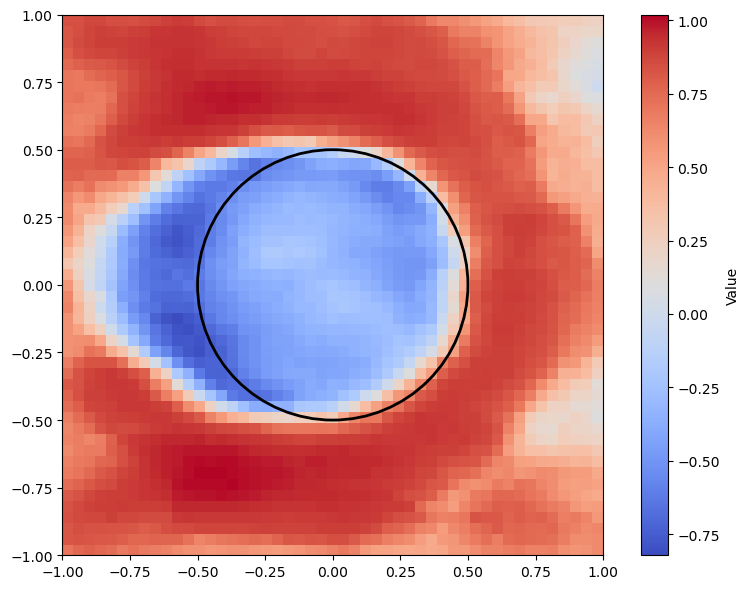

In [143]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

# Get unique x and y values
x_unique = np.unique(grid_vals[:, 0])
y_unique = np.unique(grid_vals[:, 1])

# Create grid to hold values
grid = np.zeros((len(y_unique), len(x_unique)))

# Fill grid with color values
for point in grid_vals:
    x_idx = np.where(x_unique == point[0])[0][0]
    y_idx = np.where(y_unique == point[1])[0][0]
    grid[y_idx, x_idx] = point[3]

# Create the pixelated map
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(x_unique, y_unique, grid, cmap='coolwarm', shading='flat')
plt.colorbar(mesh, label='Value')

# Add circle centered at (0,0) with radius 0.5
circle = Circle((0, 0), 0.5, fill=False, edgecolor='black', linestyle='-', linewidth=2)
ax.add_patch(circle)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()

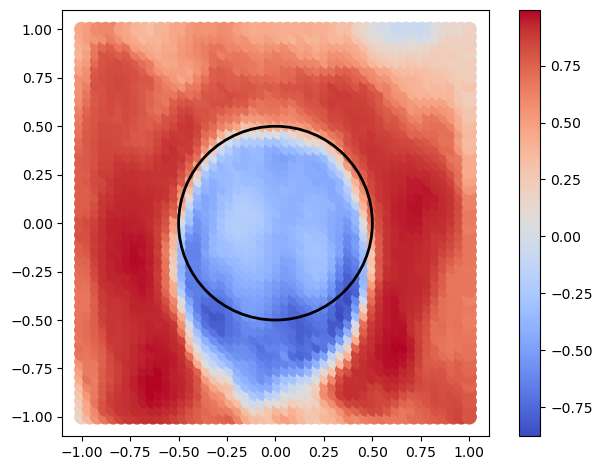

In [38]:

fig,ax = plt.subplots()
plt.scatter(grid_vals[:,0], grid_vals[:,1], c=grid_vals[:,3], cmap='coolwarm', s=100)
circle = Circle((0, 0), 0.5, fill=False, edgecolor='black', linestyle='-', linewidth=2)
ax.add_patch(circle)
ax.set_aspect('equal')
plt.tight_layout()
plt.colorbar()
plt.show()

/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages/ipykernel_launcher.py:20: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.


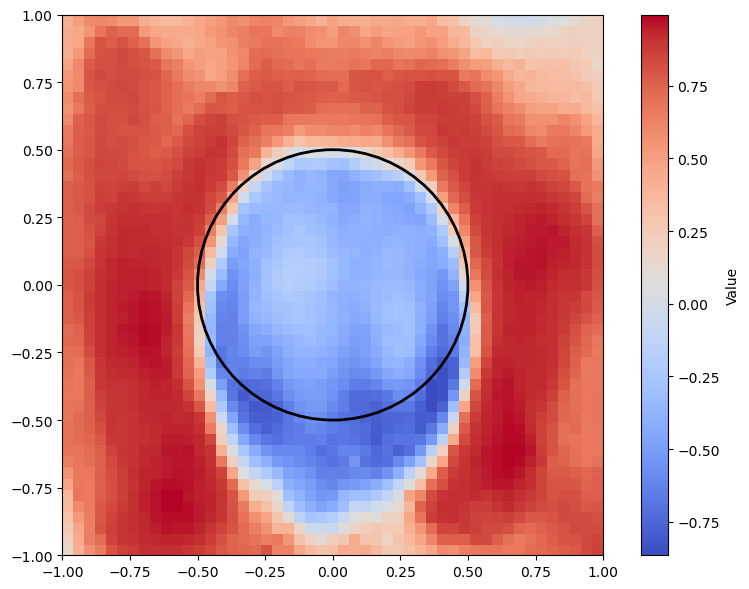

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

# Get unique x and y values
x_unique = np.unique(grid_vals[:, 0])
y_unique = np.unique(grid_vals[:, 1])

# Create grid to hold values
grid = np.zeros((len(y_unique), len(x_unique)))

# Fill grid with color values
for point in grid_vals:
    x_idx = np.where(x_unique == point[0])[0][0]
    y_idx = np.where(y_unique == point[1])[0][0]
    grid[y_idx, x_idx] = point[3]

# Create the pixelated map
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(x_unique, y_unique, grid, cmap='coolwarm', shading='flat')
plt.colorbar(mesh, label='Value')

# Add circle centered at (0,0) with radius 0.5
circle = Circle((0, 0), 0.5, fill=False, edgecolor='black', linestyle='-', linewidth=2)
ax.add_patch(circle)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()

/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages/ipykernel_launcher.py:20: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.


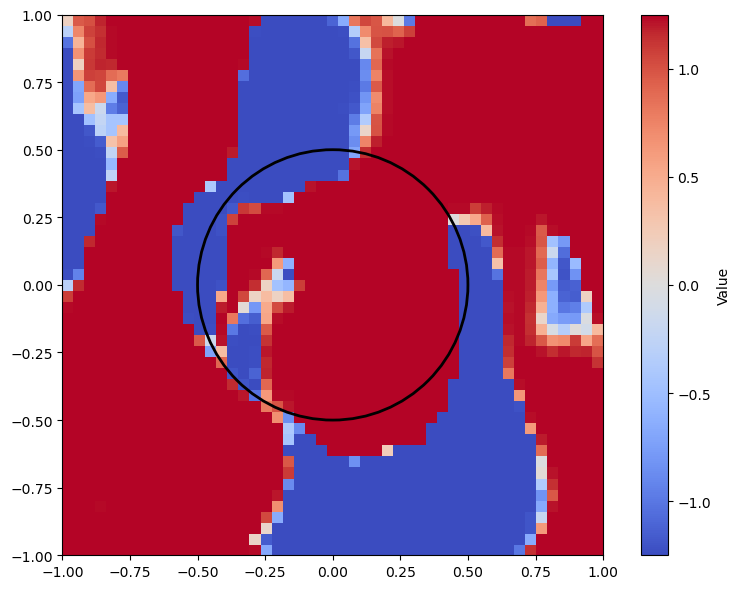

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

# Get unique x and y values
x_unique = np.unique(grid_vals[:, 0])
y_unique = np.unique(grid_vals[:, 1])

# Create grid to hold values
grid = np.zeros((len(y_unique), len(x_unique)))

# Fill grid with color values
for point in grid_vals:
    x_idx = np.where(x_unique == point[0])[0][0]
    y_idx = np.where(y_unique == point[1])[0][0]
    grid[y_idx, x_idx] = point[4]

# Create the pixelated map
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(x_unique, y_unique, grid, cmap='coolwarm', shading='flat')
plt.colorbar(mesh, label='Value')

# Add circle centered at (0,0) with radius 0.5
circle = Circle((0, 0), 0.5, fill=False, edgecolor='black', linestyle='-', linewidth=2)
ax.add_patch(circle)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()

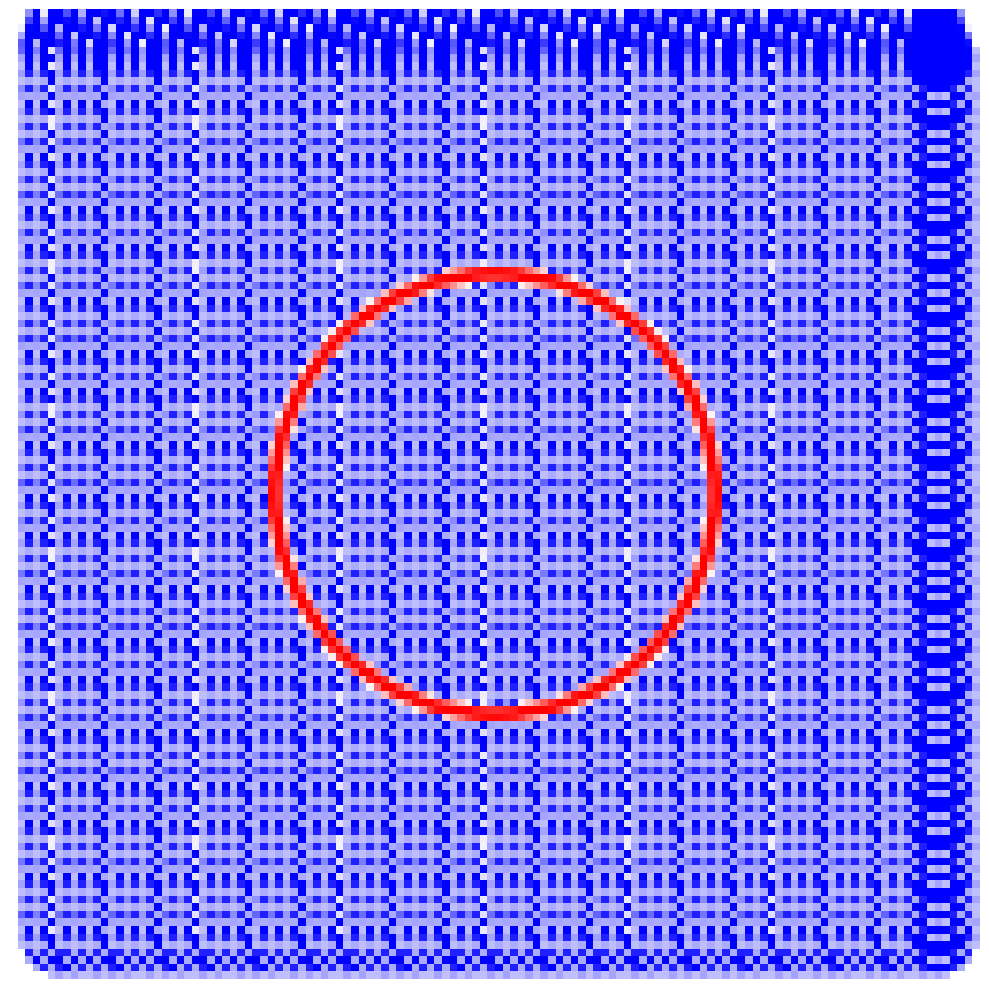

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Create a blank canvas to start with (white background with alpha)
first_img = demo_data[0]['obs']['image'][0]
composite = np.ones((*first_img.shape[:2], 4))  # RGBA
composite[..., :3] = 1.0  # White RGB
composite[..., 3] = 0.0   # Fully transparent initially

# Process and add each image to the composite
for i, traj in enumerate(demo_data):
    img = traj['obs']['image'][0]
    if img.dtype == np.uint8:
        img_float = img.astype(float) / 255.0
    else:
        img_float = img.copy()
    
    # Detect white pixels (all channels close to 1.0)
    is_white = np.all(img_float > 0.95, axis=2)
    
    # Create an alpha mask where non-white pixels have the desired alpha
    base_alpha = 1 if i == 0 else 1  # Adjust alphas as needed
    alpha_mask = np.where(is_white, 0.0, base_alpha)
    
    # Blend this image into the composite
    for c in range(3):  # For each RGB channel
        # Only update non-white pixels
        non_white = ~is_white
        
        # Add weighted color to the composite (multiply by alpha for blending)
        composite[non_white, c] = (
            composite[non_white, c] * (1 - alpha_mask[non_white]) +  # Keep existing color scaled by remaining alpha
            img_float[non_white, c] * alpha_mask[non_white]          # Add new color scaled by its alpha
        )
    
    # Update the alpha channel - make visible where any image has content
    composite[..., 3] = np.maximum(composite[..., 3], alpha_mask)

# Display the final composite image once
plt.figure(figsize=(10, 10))
plt.imshow(composite)
plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure()
for i, traj in enumerate(demo_data):
    img = traj['obs']['image'][0]
    if img.dtype == np.uint8:
        img_float = img.astype(float) / 255.0
    else:
        img_float = img.copy()
    
    rgba_img = np.ones((*img_float.shape[:2], 4))
    rgba_img[..., :3] = img_float  # Copy RGB channels
    
    # Detect white pixels (all channels close to 1.0)
    is_white = np.all(img_float > 0.95, axis=2)  # Threshold at 0.95 to handle slightly off-white
    
    # Set alpha value based on index and white detection
    base_alpha = 0.05 if i == 0 else 1.0
    rgba_img[..., 3] = np.where(is_white, 0.0, base_alpha)
    
    # Display the image with transparent whites
    plt.imshow(rgba_img)

Error in callback <function flush_figures at 0x76ea57f13200> (for post_execute):


KeyboardInterrupt: 

cpu


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

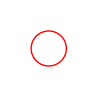